In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle

from scipy.special import sici
from scipy.integrate import quad

from scipy.optimize import curve_fit

In [2]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [3]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [4]:
def nfw_profile(r, rho0, rs):
    return rho0 / ((r / rs) * (1 + r / rs)**2)

def rho_s(mvir, r_s, c):
    rhos = (mvir/(4*np.pi*r_s**3))*(np.log(1+c) - c/(1+c))**-1
    return rhos

In [6]:


odir1 = "../ps_data/snap40/mvir"
with open(f"{odir1}/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_gal = pickle.load(f)

with open(f"{odir1}/ps-intensity-group_logM10.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_sum = pickle.load(f)


In [18]:
logks_tng = np.log10(Pk13_sum["k"])
ks_tng = Pk13_sum["k"]

In [8]:
def compute_uk2(Pk_gal10, Pk_sum10):
    ks_tng = Pk_gal10["k"]


    tot = (Pk_gal10["power"]-(Pk_sum10["power"]-Pk_sum10.attrs["shotnoise"]))
    
    shot_gal = Pk_gal10.attrs["shotnoise"]
    shot_halo = Pk_sum10.attrs["shotnoise"]
    uk2 = (tot - shot_gal)/(shot_halo - shot_gal)
    return uk2

In [20]:
uk2_tng = compute_uk2(Pk13_gal, Pk13_sum)

In [31]:
def nfw_ft_numerical(k_values, rho0, rs, rvir, rmax):

    def integrand_func(r):
        integrand = 4*np.pi* r**2 * nfw_profile(r, rho0, rs) * np.sin(k * r) / (k * r)
        return integrand

    def integrand_norm(r):
        integrand = 4*np.pi* r**2 * nfw_profile(r, rho0, rs)
        return integrand

    norm_factor = quad(integrand_norm , 0, rmax)[0]
    results = []
    for k in k_values:
        result = quad(integrand_func , 0, rmax)[0]
        results.append(result)

    return np.array(results)/norm_factor

In [59]:
p0 = [rho0, rs, rvir, 1]
bounds = ([1e10,0,0.,0.5],[1e15,0.3,1,1.5])
popt, pcov = curve_fit(nfw_ft_numerical, ks_tng, np.sqrt(uk2_tng), p0=p0, bounds=bounds)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


In [62]:
popt

array([6.16619035e+14, 3.64190401e-03, 5.00000000e-01, 1.05736681e+00])

In [65]:
c = popt[2]/popt[1]
print(c)

137.29082316228212


In [63]:
uk_numerical = nfw_ft_numerical(ks, *popt)

In [29]:
logks = np.arange(-1.5,2,0.01)
ks = 10**logks
c=100
rvir=0.5
rs = rvir/c
rho0 = rho_s(10**13, rs, c)
uk_numerical = nfw_ft_numerical(ks, rho0, rs,rvir, rmax=1)

In [48]:
logks = np.arange(-1.5,2,0.01)
ks = 10**logks
c=4
rvir=0.5
rs = rvir/c
rho0 = rho_s(10**13, rs, c)
print(np.log10(rho0))
uk_numerical = nfw_ft_numerical(ks, rho0, rs,rvir, rmax=1)

14.701876554946962


In [ ]:
logks = np.arange(-1.5,2,0.01)
ks = 10**logks
c=60
rvir=0.5
rs = rvir/c
rho0 = rho_s(10**13, rs, c)
uk_numerical2 = nfw_ft_numerical(ks, rho0, rs,rvir, rmax=1)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


(-1.55, 1.3)

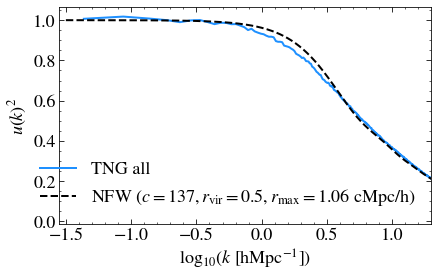

In [76]:

plt.plot(logks_tng, uk2_tng, label="TNG all",c="DodgerBlue")


plt.plot(logks, uk_numerical**2, label="NFW ($c=137, r_{\mathrm{vir}}=0.5, r_{\mathrm{max}}=$1.06 cMpc/h)", linestyle="dashed", c="k")
#plt.plot(logks, uk_numerical2**2, label="$c_{\mathrm{vir}}=60, r_{\mathrm{max}}=$1 cMpc/h", linestyle="dashed",c="grey")


plt.legend()

plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")
plt.ylabel("$u(k)^2$")
plt.xlim(-1.55,1.3)

# ax = plt.gca()
# ax.annotate(f"logM13-13.1", (0.95,0.8), xycoords="axes fraction", ha="right", weight="bold")


#plt.savefig("../figures/u_k_logM13_w_cent.pdf", format="pdf", bbox_inches="tight")